In [17]:
import numpy as np
import matplotlib.pyplot as plt





In [18]:
# I want code that creates the so-called "lobser plot", showing the
# sensitivity of a 0vbb experiment to the effective Majorana mass, 
# as a function of the unknown lightest neutrino mass. 
# The plot should show the allowed region for both normal and inverted mass hierarchies



In [19]:
def ingest_nu_global_fit_data(path="nu_global_fit_data.txt"):
    """Parse the global-fit table and return central values with asymmetric 1σ errors."""
    import os
    import re

    line_pattern = re.compile(
        r"^(?P<parameter>.*?)\t+(?P<bestfit>.*?)\t+(?P<sigma2>.*?)\t+(?P<sigma3>.*?)$"
    )
    symmetric_pattern = re.compile(
        r"^(?P<central>[-+]?\d*\.?\d+)(?:\\pm|±)(?P<error>[-+]?\d*\.?\d+)$"
    )
    asymmetric_pattern = re.compile(
        r"^(?P<central>[-+]?\d*\.?\d+)\^\{\+(?P<plus>[-+]?\d*\.?\d+)\}_\{-(?P<minus>[-+]?\d*\.?\d+)\}$"
    )

    parameters = []
    central_values = []
    err_minus = []
    err_plus = []
    sigma2_ranges = []
    sigma3_ranges = []
    raw_rows = []

    data_path = os.path.expanduser(path)
    with open(data_path, encoding="utf-8") as infile:
        lines = infile.read().splitlines()

    for raw_line in lines:
        line = raw_line.strip()
        if not line or line.startswith("parameter"):
            continue

        match = line_pattern.match(line)
        if not match:
            continue

        best_fit = match.group("bestfit").strip()
        symmetric = symmetric_pattern.match(best_fit)
        if symmetric:
            central = float(symmetric.group("central"))
            minus = plus = float(symmetric.group("error"))
        else:
            asymmetric = asymmetric_pattern.match(best_fit)
            if not asymmetric:
                raise ValueError(f"Unrecognized best-fit format: {best_fit}")
            central = float(asymmetric.group("central"))
            plus = float(asymmetric.group("plus"))
            minus = float(asymmetric.group("minus"))

        parameter = match.group("parameter").strip()
        sigma2 = match.group("sigma2").strip()
        sigma3 = match.group("sigma3").strip()

        parameters.append(parameter)
        central_values.append(central)
        err_minus.append(minus)
        err_plus.append(plus)
        sigma2_ranges.append(sigma2)
        sigma3_ranges.append(sigma3)
        raw_rows.append(
            {
                "parameter": parameter,
                "central": central,
                "err_minus": minus,
                "err_plus": plus,
                "sigma2_range": sigma2,
                "sigma3_range": sigma3,
            }
        )

    return {
        "parameter": parameters,
        "central": np.array(central_values),
        "err_minus": np.array(err_minus),
        "err_plus": np.array(err_plus),
        "yerr": np.vstack([err_minus, err_plus]),
        "sigma2_range": sigma2_ranges,
        "sigma3_range": sigma3_ranges,
        "rows": raw_rows,
    }


nu_global_fit_data = ingest_nu_global_fit_data()
# df_global_fit = pd.DataFrame(nu_global_fit_data)


In [20]:
from scipy.interpolate import interp1d


def get_best_fit_and_errors(parameter_name, ordering='NO', data_path='./ahep_globalfit_chi2/1-dim/'):
    datafile_name = data_path + parameter_name + '-' + ordering + '.dat'
    data = np.genfromtxt(datafile_name)
    
    # Get the x-values for the best-fit (where chi^2=0) and the
    # plus/minus 1σ errors (where chi^2=1)
    best_fit = data[np.argmin(data[:, 1]), 0]
    sig_region = data[np.where(data[:, 1] <= 1)[0], 0]
    error_minus = sig_region[0]
    error_plus = sig_region[-1]
    # Okay, that doesn't really work. Better to use an interpolation. 
    # Let's fit a parabola to the region near 0 and then compute the roots
    indices = np.where(data[:, 1] <= 3)[0]
    x_fit = data[indices, 0]
    y_fit = data[indices, 1]
    p = np.polyfit(x_fit, y_fit, 2)
    # Now, offset the parabola so that I can get the +/- 1sig
    a = p[0]
    b = p[1]
    c = p[2]
    min = -0.5 * b / a
    # print('Min: ', min)
    offset = c - b**2/(4*a)
    # print('Offset: ', offset)
    coeffs = [a, b, c + offset - 1]
    roots = np.roots(coeffs)
    # print('Roots: ', roots)
    error_minus = np.min(roots)
    error_plus = np.max(roots)
    best_fit = min
     
    output_dict = {'Param': parameter_name, 
                   'BestFit': best_fit, 
                   'ErrorMinus': error_minus, 
                   'ErrorPlus': error_plus}
    
    return data, p, output_dict

# Wrapper that only returns the output_dict
def get_best_fit_dict(parameter_name, ordering='NO', data_path='./ahep_globalfit_chi2/1-dim/'):
    data, p, output_dict = get_best_fit_and_errors(parameter_name, ordering, data_path)
    return output_dict
    
    
    

{'Param': 'dm31', 'BestFit': 0.002546405003095936, 'ErrorMinus': 0.0025195278394587748, 'ErrorPlus': 0.0025732821667330975}


(0.0024, 0.0026)

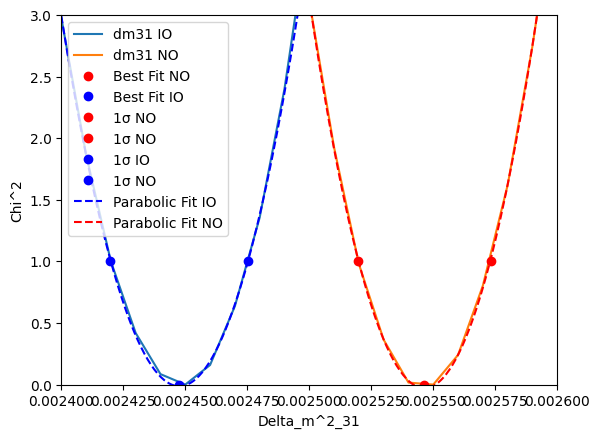

In [21]:
data_dm31_NO, p_31_NO, dm31_NO = get_best_fit_and_errors('dm31', ordering='NO')
data_dm31_IO, p_31_IO, dm31_IO = get_best_fit_and_errors('dm31', ordering='IO')

print(dm31_NO)

plt.plot(data_dm31_IO[:,0], data_dm31_IO[:,1], label='dm31 IO')
plt.plot(data_dm31_NO[:,0], data_dm31_NO[:,1], label='dm31 NO')
plt.plot(dm31_NO['BestFit'], 0, 'ro', label='Best Fit NO')
plt.plot(dm31_IO['BestFit'], 0, 'bo', label='Best Fit IO')
plt.plot(dm31_NO['ErrorMinus'], 1, 'ro', label='1σ NO')
plt.plot(dm31_NO['ErrorPlus'], 1, 'ro', label='1σ NO')
plt.plot(dm31_IO['ErrorMinus'], 1, 'bo', label='1σ IO')
plt.plot(dm31_IO['ErrorPlus'], 1, 'bo', label='1σ NO')

# let's also plot the parabolic fits
x_fit = np.linspace(0.0024, 0.0026, 300)
y_fit_IO = p_31_IO[0]*x_fit**2 + p_31_IO[1]*x_fit + p_31_IO[2]
y_fit_NO = p_31_NO[0]*x_fit**2 + p_31_NO[1]*x_fit + p_31_NO[2]
plt.plot(x_fit, y_fit_IO, 'b--', label='Parabolic Fit IO')
plt.plot(x_fit, y_fit_NO, 'r--', label='Parabolic Fit NO')


plt.xlabel('Delta_m^2_31')
plt.ylabel('Chi^2')
plt.legend()
plt.ylim(0.,3.)
plt.xlim(0.0024, 0.0026)


In [22]:
# Get all the parameter names for both orderings from the filenames
import os
import pandas as pd

files = os.listdir('./ahep_globalfit_chi2/1-dim/')
parameters_NO = set()
parameters_IO = set()

for filename in files:
    if filename.endswith('-NO.dat'):
        param_name = filename.split('-')[0]  # Get the part before '-NO.dat'
        parameters_NO.add(param_name)
    elif filename.endswith('-IO.dat'):
        param_name = filename.split('-')[0]  # Get the part before '-IO.dat'
        parameters_IO.add(param_name)
        
        
print(parameters_IO)

# Now let's loop through all these files and create a list of output_dicts for each parameter
params_list_NO = []
params_list_IO = []
for param in parameters_NO:
    params_list_NO.append( get_best_fit_dict(param, ordering='NO') )
    params_list_IO.append( get_best_fit_dict(param, ordering='IO') )
    
df_NO = pd.DataFrame(params_list_NO)
df_IO = pd.DataFrame(params_list_IO)



{'sq12', 'sq23', 'del', 'dm21', 'sq13', 'dm31'}


In [23]:
df_IO.head(n=100)

,Param,BestFit,ErrorMinus,ErrorPlus
0,sq12,0.318467,0.302182,0.334752
1,sq23,0.573014,0.559619,0.586408
2,del,1.566940,1.415725,1.718155
3,dm21,0.000075,0.000073,0.000077
4,sq13,0.022198,0.021522,0.022874
5,dm31,0.002448,0.002420,0.002475


In [24]:
df_NO.head(n=100)

,Param,BestFit,ErrorMinus,ErrorPlus
0,sq12,0.318467,0.302182,0.334752
1,sq23,0.573131,0.559366,0.586896
2,del,1.096264,0.970361,1.222167
3,dm21,0.000075,0.000073,0.000077
4,sq13,0.022019,0.021339,0.022699
5,dm31,0.002546,0.002520,0.002573


In [25]:
# Okay, now I need the formula for the effective Majorana mass, 
# which is a function of the lightest neutrino mass and the mixing parameters. 
# I can use the best-fit values and errors from the global fit to compute the 
# allowed region for the effective Majorana mass as a 
# function of the lightest neutrino mass.

#|mββ | = √(c212c213m1 + s212c213m2 cos α + s213m3 cos β)2++(s212c213m2 sin α + s213m3 sin β)2

# The params_dict here will be a simple table to look up the value of a parameter by
# its name. This will allow me to fluctuate the values later and not need to 
# change this function

def majorana_mass( params_dict, ordering='NO', delta_a1 = 0., delta_a2 = 0., m_l=0.):
    
    if ordering == 'NO':
        m1 = m_l
        m2 = np.sqrt(m1**2 + params_dict['dm21'])
        m3 = np.sqrt(m2**2 + params_dict['dm31'])
    elif ordering == 'IO':
        m3 = m_l
        m1 = np.sqrt(m3**2 + params_dict['dm31'])
        m2 = np.sqrt(m1**2 + params_dict['dm21'])
    
    theta12 = np.arcsin(np.sqrt(params_dict['sq12']))
    theta13 = np.arcsin(np.sqrt(params_dict['sq13']))
            
    Ue1sq = (np.cos(theta12)*np.cos(theta13))**2
    Ue2sq = (np.sin(theta12)*np.cos(theta13))**2
    Ue3sq = (np.sin(theta13))**2

    mbb = np.abs(Ue1sq*m1 + Ue2sq*m2*np.exp(1j*delta_a1) + Ue3sq*m3*np.exp(1j*delta_a2))
    return mbb


{'sq12': 0.318466718409247, 'sq23': 0.5731308400144471, 'del': 1.096263946373627, 'dm21': 7.503887305802004e-05, 'sq13': 0.022018730056348638, 'dm31': 0.002546405003095936}


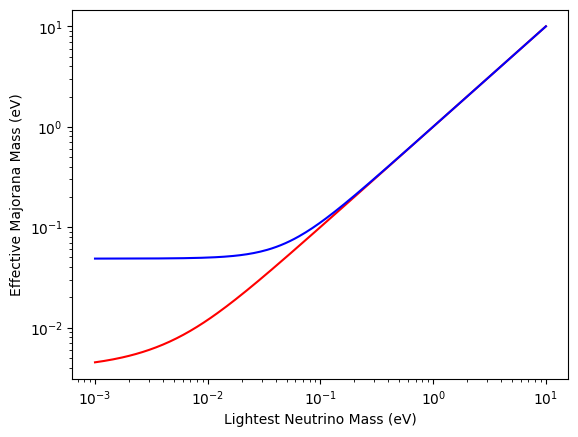

In [26]:
params_dict_NO = dict(df_NO[['Param','BestFit']].values)
params_dict_IO = dict(df_IO[['Param','BestFit']].values)

print(params_dict_NO)


m_l = np.logspace(-3., 1, 200)
mbb_NO = majorana_mass(params_dict_NO, ordering='NO', m_l=m_l)
mbb_IO = majorana_mass(params_dict_IO, ordering='IO', m_l=m_l)

plt.plot(m_l, mbb_NO, label='NO', color='red')
plt.plot(m_l, mbb_IO, label='IO', color='blue')
plt.xlabel('Lightest Neutrino Mass (eV)')
plt.ylabel('Effective Majorana Mass (eV)')
plt.xscale('log')
plt.yscale('log')

(0.0001, 1.0)

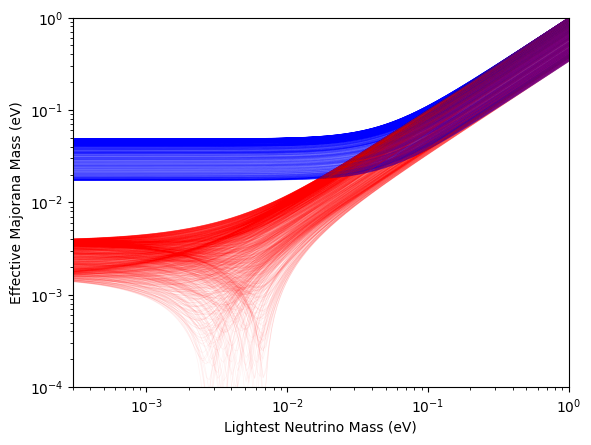

In [27]:
m_l = np.logspace(-4., 0., 200)

for i in range(2000):
    
    delta_a1 = np.random.uniform(0., 2.*np.pi) 
    delta_a2 = np.random.uniform(0., 2.*np.pi)
    
    mbb_NO = majorana_mass(params_dict_NO, ordering='NO', \
        delta_a1 = delta_a1, delta_a2 = delta_a2, m_l=m_l)
    mbb_IO = majorana_mass(params_dict_IO, ordering='IO', \
        delta_a1 = delta_a1, delta_a2 = delta_a2, m_l=m_l)
    plt.plot(m_l, mbb_NO, label='NO', color=(1.,0.,0.,0.05), linewidth=0.5)
    plt.plot(m_l, mbb_IO, label='IO', color=(0.,0.,1.,0.05), linewidth=0.5)
    
plt.xlabel('Lightest Neutrino Mass (eV)')
plt.ylabel('Effective Majorana Mass (eV)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(3e-4, 1.)
plt.ylim(1e-4, 1.)

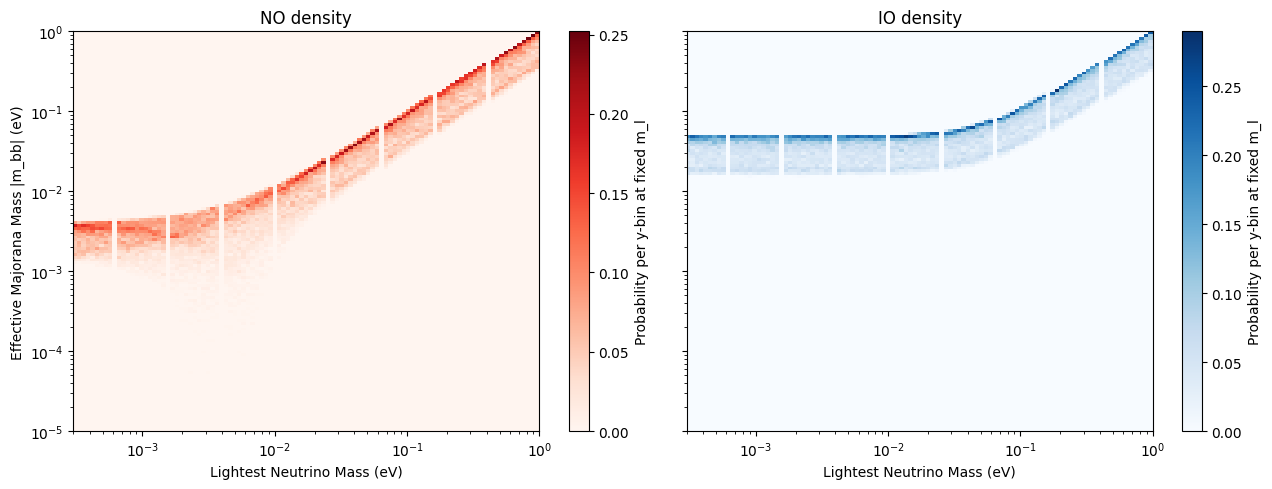

In [28]:
def _infer_ordering_from_params_dict(params_dict, ordering=None):
    """Infer ordering from the exact params_dict object if not provided."""
    if ordering in ('NO', 'IO'):
        return ordering

    if params_dict is params_dict_NO:
        return 'NO'
    if params_dict is params_dict_IO:
        return 'IO'

    raise ValueError("Could not infer ordering. Pass ordering='NO' or ordering='IO'.")


def _one_sigma_ranges_for_params_dict(params_dict, ordering=None):
    """Return {param: (low, high)} for the supplied params_dict_NO or params_dict_IO."""
    inferred_ordering = _infer_ordering_from_params_dict(params_dict, ordering=ordering)
    df_ref = df_NO if inferred_ordering == 'NO' else df_IO

    ranges = {}
    for _, row in df_ref.iterrows():
        low = min(row['ErrorMinus'], row['ErrorPlus'])
        high = max(row['ErrorMinus'], row['ErrorPlus'])
        ranges[row['Param']] = (low, high)
    return ranges, inferred_ordering


def sample_params_1sigma(params_dict, ordering=None, rng=None):
    """Sample each parameter uniformly in its 1σ interval for this params_dict."""
    if rng is None:
        rng = np.random.default_rng()

    one_sigma, _ = _one_sigma_ranges_for_params_dict(params_dict, ordering=ordering)

    sampled = {}
    for param_name, best_fit in params_dict.items():
        if param_name in one_sigma:
            low, high = one_sigma[param_name]
            sampled[param_name] = rng.uniform(low, high)
        else:
            sampled[param_name] = best_fit

    return sampled


def sample_mbb_at_mlightest(m_l_value, params_dict, ordering=None, n_samples=1000, rng=None):
    """
    Draw |m_bb| samples for a fixed m_lightest by fluctuating:
    - all oscillation parameters in their 1σ intervals
    - Majorana phases uniformly in [0, 2π)
    """
    if rng is None:
        rng = np.random.default_rng()

    inferred_ordering = _infer_ordering_from_params_dict(params_dict, ordering=ordering)

    mbb_samples = np.empty(n_samples)
    for i in range(n_samples):
        params_draw = sample_params_1sigma(params_dict, ordering=inferred_ordering, rng=rng)
        delta_a1 = rng.uniform(0.0, 2.0 * np.pi)
        delta_a2 = rng.uniform(0.0, 2.0 * np.pi)
        mbb_samples[i] = majorana_mass(
            params_draw,
            ordering=inferred_ordering,
            delta_a1=delta_a1,
            delta_a2=delta_a2,
            m_l=m_l_value,
        )
    return mbb_samples


def generate_mbb_density_samples(params_dict, ordering=None, m_l_grid=None, n_samples_per_m=500, rng=None):
    """Generate (m_lightest, |m_bb|) point cloud for 2D histogram density plots."""
    if rng is None:
        rng = np.random.default_rng()
    if m_l_grid is None:
        m_l_grid = np.logspace(-4.0, 0.0, 120)

    inferred_ordering = _infer_ordering_from_params_dict(params_dict, ordering=ordering)

    m_points = np.repeat(m_l_grid, n_samples_per_m)
    mbb_points = np.empty_like(m_points)

    start = 0
    for m_val in m_l_grid:
        draws = sample_mbb_at_mlightest(
            m_val,
            params_dict,
            ordering=inferred_ordering,
            n_samples=n_samples_per_m,
            rng=rng,
        )
        stop = start + n_samples_per_m
        mbb_points[start:stop] = draws
        start = stop

    return m_points, mbb_points


# Settings for the density plot
import os
import pickle

sample_cache_path = os.path.join('.', 'mbb_density_samples.pkl')


def save_sample_cache(cache_path, cache_payload):
    with open(cache_path, 'wb') as cache_file:
        pickle.dump(cache_payload, cache_file, protocol=pickle.HIGHEST_PROTOCOL)


def load_sample_cache(cache_path):
    with open(cache_path, 'rb') as cache_file:
        return pickle.load(cache_file)


rng = np.random.default_rng(7)
m_l_grid = np.logspace(-4.0, 0.0, 110)
n_samples_per_m = 500

# Build sample clouds from the same params_dict_NO / params_dict_IO defined above
if os.path.exists(sample_cache_path):
    sample_cache = load_sample_cache(sample_cache_path)
    m_no = sample_cache['m_no']
    mbb_no = sample_cache['mbb_no']
    m_io = sample_cache['m_io']
    mbb_io = sample_cache['mbb_io']
else:
    m_no, mbb_no = generate_mbb_density_samples(
        params_dict_NO,
        m_l_grid=m_l_grid,
        n_samples_per_m=n_samples_per_m,
        rng=rng,
    )
    m_io, mbb_io = generate_mbb_density_samples(
        params_dict_IO,
        m_l_grid=m_l_grid,
        n_samples_per_m=n_samples_per_m,
        rng=rng,
    )
    sample_cache = {
        'config': {
            'rng_seed': 7,
            'm_l_grid': m_l_grid,
            'n_samples_per_m': n_samples_per_m,
        },
        'm_no': m_no,
        'mbb_no': mbb_no,
        'm_io': m_io,
        'mbb_io': mbb_io,
    }
    save_sample_cache(sample_cache_path, sample_cache)

# 2D histogram bins (log-spaced)
x_bins = np.logspace(-4.0, 0.0, 120)
y_bins = np.logspace(-5.0, 0.0, 140)

H_no, x_edges, y_edges = np.histogram2d(m_no, mbb_no, bins=[x_bins, y_bins])
H_io, _, _ = np.histogram2d(m_io, mbb_io, bins=[x_bins, y_bins])

# Normalize each m_l column to get p(|m_bb| | m_l) in each y-bin
colsum_no = H_no.sum(axis=1, keepdims=True)
colsum_io = H_io.sum(axis=1, keepdims=True)
H_no_pdf = np.divide(H_no, colsum_no, out=np.zeros_like(H_no), where=colsum_no > 0)
H_io_pdf = np.divide(H_io, colsum_io, out=np.zeros_like(H_io), where=colsum_io > 0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

pcm_no = axes[0].pcolormesh(x_edges, y_edges, H_no_pdf.T, shading='auto', cmap='Reds')
axes[0].set_title('NO density')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Lightest Neutrino Mass (eV)')
axes[0].set_ylabel('Effective Majorana Mass |m_bb| (eV)')
axes[0].set_xlim(3e-4, 1.0)
axes[0].set_ylim(1e-5, 1.0)
cb_no = fig.colorbar(pcm_no, ax=axes[0])
cb_no.set_label('Probability per y-bin at fixed m_l')

pcm_io = axes[1].pcolormesh(x_edges, y_edges, H_io_pdf.T, shading='auto', cmap='Blues')
axes[1].set_title('IO density')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Lightest Neutrino Mass (eV)')
axes[1].set_xlim(3e-4, 1.0)
axes[1].set_ylim(1e-5, 1.0)
cb_io = fig.colorbar(pcm_io, ax=axes[1])
cb_io.set_label('Probability per y-bin at fixed m_l')

plt.tight_layout()
plt.show()

In [30]:
def neutrino_masses(m_lightest, dm21, dm31, ordering="NO"):
    """Return (m1, m2, m3) in eV for a given lightest mass and mass splittings."""
    ordering = ordering.upper()
    dm21 = float(dm21)
    dm31 = abs(float(dm31))

    if ordering == "NO":
        m1 = m_lightest
        m2 = np.sqrt(m1**2 + dm21)
        m3 = np.sqrt(m1**2 + dm31)
    elif ordering == "IO":
        m3 = m_lightest
        m1 = np.sqrt(m3**2 + dm31)
        m2 = np.sqrt(m3**2 + dm31 + dm21)
    else:
        raise ValueError("ordering must be 'NO' or 'IO'")

    return m1, m2, m3


def sum_masses(m_lightest, dm21, dm31, ordering="NO"):
    m1, m2, m3 = neutrino_masses(m_lightest, dm21, dm31, ordering)
    return m1 + m2 + m3


def solve_lightest_from_sum(sum_target, dm21, dm31, ordering="NO", m_hi=1.0, rtol=1e-12, maxiter=300):
    """Solve for m_lightest such that sum_masses(m_lightest) == sum_target."""
    ordering = ordering.upper()

    s_min = sum_masses(0.0, dm21, dm31, ordering)
    if sum_target < s_min:
        raise ValueError(
            f"Target sum {sum_target:.6f} eV is below the minimum {s_min:.6f} eV for {ordering}."
        )

    def f(m):
        return sum_masses(m, dm21, dm31, ordering) - sum_target

    lo, hi = 0.0, float(m_hi)
    while f(hi) < 0:
        hi *= 2.0
        if hi > 100:
            raise RuntimeError("Failed to bracket m_lightest solution.")

    for _ in range(maxiter):
        mid = 0.5 * (lo + hi)
        if f(mid) > 0:
            hi = mid
        else:
            lo = mid
        if abs(hi - lo) <= rtol * max(1.0, abs(mid)):
            break

    return 0.5 * (lo + hi)


def cosmological_lightest_limits(sum_m_nu, params_dict_NO, params_dict_IO):
    """Return max allowed m_lightest for NO and IO at fixed sum_m_nu bound."""
    dm21_no = params_dict_NO["dm21"]
    dm31_no = params_dict_NO["dm31"]
    dm21_io = params_dict_IO["dm21"]
    dm31_io = params_dict_IO["dm31"]

    m_l_NO_max = solve_lightest_from_sum(sum_m_nu, dm21_no, dm31_no, ordering="NO")
    m_l_IO_max = solve_lightest_from_sum(sum_m_nu, dm21_io, dm31_io, ordering="IO")

    return m_l_NO_max, m_l_IO_max


# Cosmological 95% CL upper bound from DESI (w0-wa model)
sum_m_nu = 0.163

m_l_NO_max, m_l_IO_max = cosmological_lightest_limits(sum_m_nu, params_dict_NO, params_dict_IO)

print(f"Cosmological bound: Σmν < {sum_m_nu:.3f} eV")
print(f"Maximum allowed lightest mass (NO): {m_l_NO_max:.5f} eV")
print(f"Maximum allowed lightest mass (IO): {m_l_IO_max:.5f} eV")

# Optional consistency check: plugging back in should reproduce the bound
print(f"Check NO sum: {sum_masses(m_l_NO_max, params_dict_NO['dm21'], params_dict_NO['dm31'], 'NO'):.6f} eV")
print(f"Check IO sum: {sum_masses(m_l_IO_max, params_dict_IO['dm21'], params_dict_IO['dm31'], 'IO'):.6f} eV")

Cosmological bound: Σmν < 0.163 eV
Maximum allowed lightest mass (NO): 0.04672 eV
Maximum allowed lightest mass (IO): 0.03784 eV
Check NO sum: 0.163000 eV
Check IO sum: 0.163000 eV


In [31]:
# Cosmological 95% CL upper bound from DESI (w0-wa model)
sum_m_nu = 0.163

# Use the robust solver defined in the previous box
m_l_NO_max, m_l_IO_max = cosmological_lightest_limits(sum_m_nu, params_dict_NO, params_dict_IO)

print("Cosmological limit on the lightest neutrino mass:")
print(f"NO ordering: {m_l_NO_max:.5f} eV")
print(f"IO ordering: {m_l_IO_max:.5f} eV")

Cosmological limit on the lightest neutrino mass:
NO ordering: 0.04672 eV
IO ordering: 0.03784 eV


In [32]:
# Sample generation + histogram preparation only (no plotting)
# This cell can be run once, then plotting cells can be iterated quickly.
import os
import pickle

# Reduced sampling by 2x compared to previous setting.
rng_seed = 7
m_l_grid_plot = np.logspace(-4.0, 0.0, 110)
n_samples_per_m_plot = 1250


def x_edges_from_grid(grid):
    logg = np.log10(grid)
    edges_log = np.empty(grid.size + 1)
    edges_log[1:-1] = 0.5 * (logg[:-1] + logg[1:])
    edges_log[0] = logg[0] - 0.5 * (logg[1] - logg[0])
    edges_log[-1] = logg[-1] + 0.5 * (logg[-1] - logg[-2])
    return 10**edges_log


def save_sample_cache(cache_path, cache_payload):
    with open(cache_path, 'wb') as cache_file:
        pickle.dump(cache_payload, cache_file, protocol=pickle.HIGHEST_PROTOCOL)


def load_sample_cache(cache_path):
    with open(cache_path, 'rb') as cache_file:
        return pickle.load(cache_file)


# Reuse cached samples if configuration is unchanged.
sample_cache_path = 'mbb_density_samples.pkl'
sample_config = (rng_seed, len(m_l_grid_plot), n_samples_per_m_plot)
cache_ready = (
    os.path.exists(sample_cache_path)
    and 'sample_config_cached' in globals()
    and sample_config_cached == sample_config
    and 'm_no' in globals() and 'mbb_no' in globals()
    and 'm_io' in globals() and 'mbb_io' in globals()
)

if cache_ready:
    print('Reusing cached samples and histograms.')
else:
    rng = np.random.default_rng(rng_seed)
    m_no, mbb_no = generate_mbb_density_samples(
        params_dict_NO,
        m_l_grid=m_l_grid_plot,
        n_samples_per_m=n_samples_per_m_plot,
        rng=rng,
    )
    m_io, mbb_io = generate_mbb_density_samples(
        params_dict_IO,
        m_l_grid=m_l_grid_plot,
        n_samples_per_m=n_samples_per_m_plot,
        rng=rng,
    )

    x_bins = x_edges_from_grid(m_l_grid_plot)
    y_bins = np.logspace(-5.0, 0.0, 170)

    H_no, x_edges, y_edges = np.histogram2d(m_no, mbb_no, bins=[x_bins, y_bins])
    H_io, _, _ = np.histogram2d(m_io, mbb_io, bins=[x_bins, y_bins])

    colsum_no = H_no.sum(axis=1, keepdims=True)
    colsum_io = H_io.sum(axis=1, keepdims=True)
    H_no_pdf = np.divide(H_no, colsum_no, out=np.zeros_like(H_no), where=colsum_no > 0)
    H_io_pdf = np.divide(H_io, colsum_io, out=np.zeros_like(H_io), where=colsum_io > 0)

    H_no_pdf_masked = np.ma.masked_less_equal(H_no_pdf, 0.0)
    H_io_pdf_masked = np.ma.masked_less_equal(H_io_pdf, 0.0)

    positive_vals = np.concatenate([
        H_no_pdf[H_no_pdf > 0.0],
        H_io_pdf[H_io_pdf > 0.0],
    ])
    vmin = positive_vals.min()
    vmax = positive_vals.max()

    sample_config_cached = sample_config

    # Save the raw samples so future runs can skip regeneration.
    sample_cache = {
        'config': {
            'rng_seed': rng_seed,
            'm_l_grid': m_l_grid_plot,
            'n_samples_per_m': n_samples_per_m_plot,
        },
        'm_no': m_no,
        'mbb_no': mbb_no,
        'm_io': m_io,
        'mbb_io': mbb_io,
    }
    save_sample_cache(sample_cache_path, sample_cache)

# Cosmology limits and meV-converted plotting arrays
if 'm_l_NO_max' not in globals() or 'm_l_IO_max' not in globals():
    sum_m_nu = 0.163
    m_l_NO_max, m_l_IO_max = cosmological_lightest_limits(sum_m_nu, params_dict_NO, params_dict_IO)

x_edges_meV = x_edges * 1e3
y_edges_meV = y_edges * 1e3
m_l_NO_max_meV = m_l_NO_max * 1e3
m_l_IO_max_meV = m_l_IO_max * 1e3

print(f'Sample grid points: {len(m_l_grid_plot)}')
print(f'Samples per m_l: {n_samples_per_m_plot}')
print(f'Points per ordering: {m_no.size:,}')
print(f'NO cosmology cutoff: {m_l_NO_max_meV:.2f} meV')
print(f'IO cosmology cutoff: {m_l_IO_max_meV:.2f} meV')

Sample grid points: 110
Samples per m_l: 1250
Points per ordering: 137,500
NO cosmology cutoff: 46.72 meV
IO cosmology cutoff: 37.84 meV


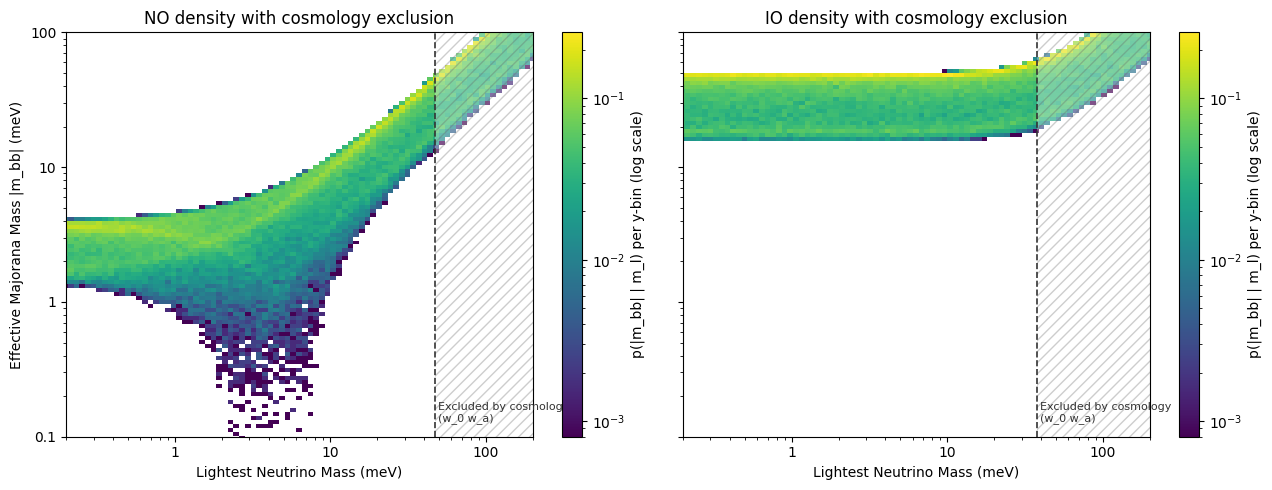

In [33]:
# Plot-only cell (fast): density with cosmology exclusion in meV
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter

_fmt = FuncFormatter(lambda x, _: f'{x:g}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

uniform_cmap = plt.get_cmap('viridis').copy()
uniform_cmap.set_bad(alpha=0.0)
norm = LogNorm(vmin=vmin, vmax=vmax)

pcm_no = axes[0].pcolormesh(x_edges_meV, y_edges_meV, H_no_pdf_masked.T, shading='auto', cmap=uniform_cmap, norm=norm)
axes[0].set_title('NO density with cosmology exclusion')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Lightest Neutrino Mass (meV)')
axes[0].set_ylabel('Effective Majorana Mass |m_bb| (meV)')
axes[0].set_xlim(2e-1, 2e2)
axes[0].set_ylim(1e-1, 1e2)
axes[0].axvspan(m_l_NO_max_meV, x_edges_meV[-1], facecolor='white', alpha=0.32, hatch='///', edgecolor='0.4', linewidth=0.0)
axes[0].axvline(m_l_NO_max_meV, color='0.2', linestyle='--', linewidth=1.2)
axes[0].text(1.05 * m_l_NO_max_meV, 1.3e-1, 'Excluded by cosmology\n(w_0 w_a)', fontsize=8, color='0.2')
cb_no = fig.colorbar(pcm_no, ax=axes[0])
cb_no.set_label('p(|m_bb| | m_l) per y-bin (log scale)')

pcm_io = axes[1].pcolormesh(x_edges_meV, y_edges_meV, H_io_pdf_masked.T, shading='auto', cmap=uniform_cmap, norm=norm)
axes[1].set_title('IO density with cosmology exclusion')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Lightest Neutrino Mass (meV)')
axes[1].set_xlim(2e-1, 2e2)
axes[1].set_ylim(1e-1, 1e2)
axes[1].axvspan(m_l_IO_max_meV, x_edges_meV[-1], facecolor='white', alpha=0.32, hatch='///', edgecolor='0.4', linewidth=0.0)
axes[1].axvline(m_l_IO_max_meV, color='0.2', linestyle='--', linewidth=1.2)
axes[1].text(1.05 * m_l_IO_max_meV, 1.3e-1, 'Excluded by cosmology\n(w_0 w_a)', fontsize=8, color='0.2')
cb_io = fig.colorbar(pcm_io, ax=axes[1])
cb_io.set_label('p(|m_bb| | m_l) per y-bin (log scale)')

for _ax in axes:
    _ax.xaxis.set_major_formatter(_fmt)
    _ax.yaxis.set_major_formatter(_fmt)

plt.tight_layout()
# plt.show()

In [34]:
# Nuclear matrix element ranges. The "ab-inito"
# calculations come from the TRIUMF VS-IMSRG calculations
# and the pheno come from a mix of calculations. All are given in https://arxiv.org/pdf/2606.09288


NME_ab_initio = {'lower': 1.08,
                 'upper': 1.90}
NME_pheno = {'lower': 1.98,
             'upper': 5.06}

G = 14.58e-15 # Phase space factor for 136Xe in units of 1/yr
g_A = 1.273
# g_A = 1
m_e = 0.511e6 # electron mass in eV

halflife_80t = {'upper': 1.3e28, 
                'lower': 8.0e27}

halflife_80t_discovery = {'upper': 5.76e27,
                          'lower': 3.81e27}


halflife_60t = {'upper': 9.4e27, 
                'lower': 5.8e27}

halflife_60t_discovery = {'upper': 4.06e27,
                          'lower': 2.64e27}


mbb_ab_initio_80t = {'upper': np.sqrt( 1.0 / (G * g_A**4 * NME_ab_initio['upper']**2 * halflife_80t_discovery['upper']) ) * m_e,
                     'lower': np.sqrt( 1.0 / (G * g_A**4 * NME_ab_initio['lower']**2 * halflife_80t_discovery['lower']) ) * m_e}
mbb_ab_initio_60t = {'upper': np.sqrt( 1.0 / (G * g_A**4 * NME_ab_initio['upper']**2 * halflife_60t_discovery['upper']) ) * m_e,
                     'lower': np.sqrt( 1.0 / (G * g_A**4 * NME_ab_initio['lower']**2 * halflife_60t_discovery['lower']) ) * m_e}
mbb_pheno_80t = {'upper': np.sqrt( 1.0 / (G * g_A**4 * NME_pheno['upper']**2 * halflife_80t_discovery['upper']) ) * m_e,
            'lower': np.sqrt( 1.0 / (G * g_A**4 * NME_pheno['lower']**2 * halflife_80t_discovery['lower']) ) * m_e}
mbb_pheno_60t = {'upper': np.sqrt( 1.0 / (G * g_A**4 * NME_pheno['upper']**2 * halflife_60t_discovery['upper']) ) * m_e,
            'lower': np.sqrt( 1.0 / (G * g_A**4 * NME_pheno['lower']**2 * halflife_60t_discovery['lower']) ) * m_e}

# Print these in meV
print(f"Ab-initio: {mbb_ab_initio_80t['lower']*1e3:.2f} meV > |m_bb| > {mbb_ab_initio_80t['upper']*1e3:.2f} meV")
print(f"Pheno: {mbb_pheno_80t['lower']*1e3:.2f} meV > |m_bb| > {mbb_pheno_80t['upper']*1e3:.2f} meV")   





Ab-initio: 39.17 meV > |m_bb| > 18.11 meV
Pheno: 21.37 meV > |m_bb| > 6.80 meV


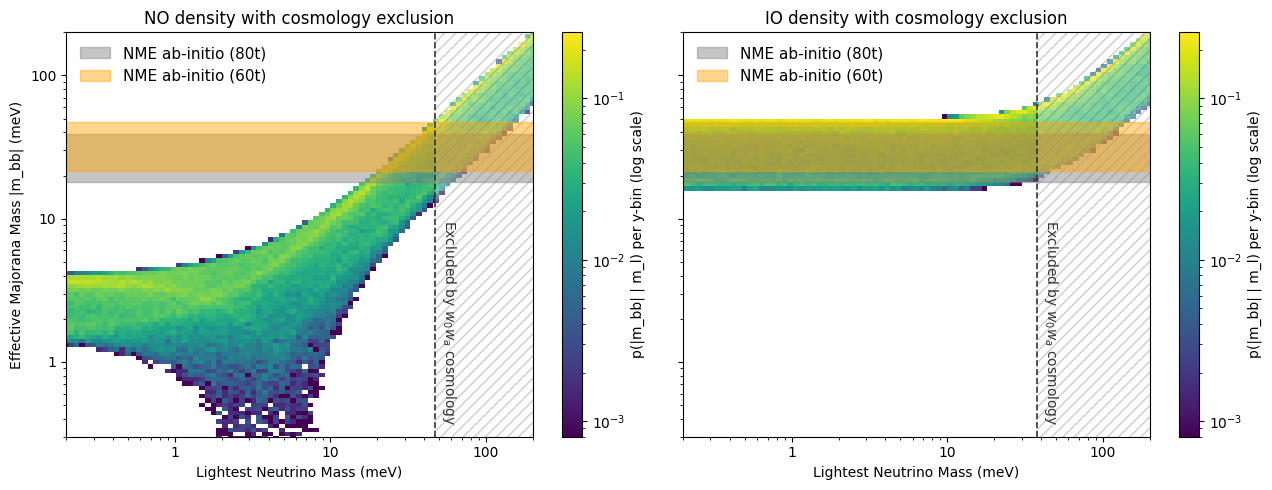

In [35]:
# Same density plot as above, now with NME bands overlaid (all axes in meV)
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter

_fmt = FuncFormatter(lambda x, _: f'{x:g}')

# Convert edges and cosmology limits to meV for plotting.
x_edges_meV = x_edges * 1e3
y_edges_meV = y_edges * 1e3
m_l_NO_max_meV = m_l_NO_max * 1e3
m_l_IO_max_meV = m_l_IO_max * 1e3

# NME bands to meV
mbb_ab_initio_80t_meV = {k: v * 1e3 for k, v in mbb_ab_initio_80t.items()}
mbb_ab_initio_60t_meV = {k: v * 1e3 for k, v in mbb_ab_initio_60t.items()}
mbb_pheno_80t_meV = {k: v * 1e3 for k, v in mbb_pheno_80t.items()}
mbb_pheno_60t_meV = {k: v * 1e3 for k, v in mbb_pheno_60t.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

uniform_cmap = plt.get_cmap('viridis').copy()
uniform_cmap.set_bad(alpha=0.0)
norm = LogNorm(vmin=vmin, vmax=vmax)

pcm_no = axes[0].pcolormesh(x_edges_meV, y_edges_meV, H_no_pdf_masked.T, shading='auto', cmap=uniform_cmap, norm=norm)
axes[0].set_title('NO density with cosmology exclusion')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Lightest Neutrino Mass (meV)')
axes[0].set_ylabel('Effective Majorana Mass |m_bb| (meV)')
axes[0].set_xlim(2e-1, 2e2)
axes[0].set_ylim(3e-1, 2e2)
axes[0].axvspan(m_l_NO_max_meV, x_edges_meV[-1], facecolor='white', alpha=0.32, hatch='///', edgecolor='0.4', linewidth=0.0)
axes[0].axvline(m_l_NO_max_meV, color='0.2', linestyle='--', linewidth=1.2)
axes[0].text(1.08 * m_l_NO_max_meV, 3.9e-1, 'Excluded by $w_0 w_a$ cosmology', fontsize=10, color='0.2', rotation=270)
cb_no = fig.colorbar(pcm_no, ax=axes[0])
cb_no.set_label('p(|m_bb| | m_l) per y-bin (log scale)')

pcm_io = axes[1].pcolormesh(x_edges_meV, y_edges_meV, H_io_pdf_masked.T, shading='auto', cmap=uniform_cmap, norm=norm)
axes[1].set_title('IO density with cosmology exclusion')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Lightest Neutrino Mass (meV)')
axes[1].set_xlim(2e-1, 2e2)
axes[1].set_ylim(3e-1, 2e2)
axes[1].axvspan(m_l_IO_max_meV, x_edges_meV[-1], facecolor='white', alpha=0.32, hatch='///', edgecolor='0.4', linewidth=0.0)
axes[1].axvline(m_l_IO_max_meV, color='0.2', linestyle='--', linewidth=1.2)
axes[1].text(1.08 * m_l_IO_max_meV, 3.9e-1, 'Excluded by $w_0 w_a$ cosmology', fontsize=10, color='0.2', rotation=270)
cb_io = fig.colorbar(pcm_io, ax=axes[1])
cb_io.set_label('p(|m_bb| | m_l) per y-bin (log scale)')

# NME sensitivity bands (meV)
axes[0].fill_between(x_edges_meV, mbb_ab_initio_80t_meV['lower'], mbb_ab_initio_80t_meV['upper'], color='gray', alpha=0.45, label='NME ab-initio (80t)')
axes[0].fill_between(x_edges_meV, mbb_ab_initio_60t_meV['lower'], mbb_ab_initio_60t_meV['upper'], color='orange', alpha=0.45, label='NME ab-initio (60t)')

axes[1].fill_between(x_edges_meV, mbb_ab_initio_80t_meV['lower'], mbb_ab_initio_80t_meV['upper'], color='gray', alpha=0.45, label='NME ab-initio (80t)')
axes[1].fill_between(x_edges_meV, mbb_ab_initio_60t_meV['lower'], mbb_ab_initio_60t_meV['upper'], color='orange', alpha=0.45, label='NME ab-initio (60t)')

axes[0].legend(loc='upper left', fontsize=11, frameon=False)
axes[1].legend(loc='upper left', fontsize=11, frameon=False)

for _ax in axes:
    _ax.xaxis.set_major_formatter(_fmt)
    _ax.yaxis.set_major_formatter(_fmt)

plt.tight_layout()

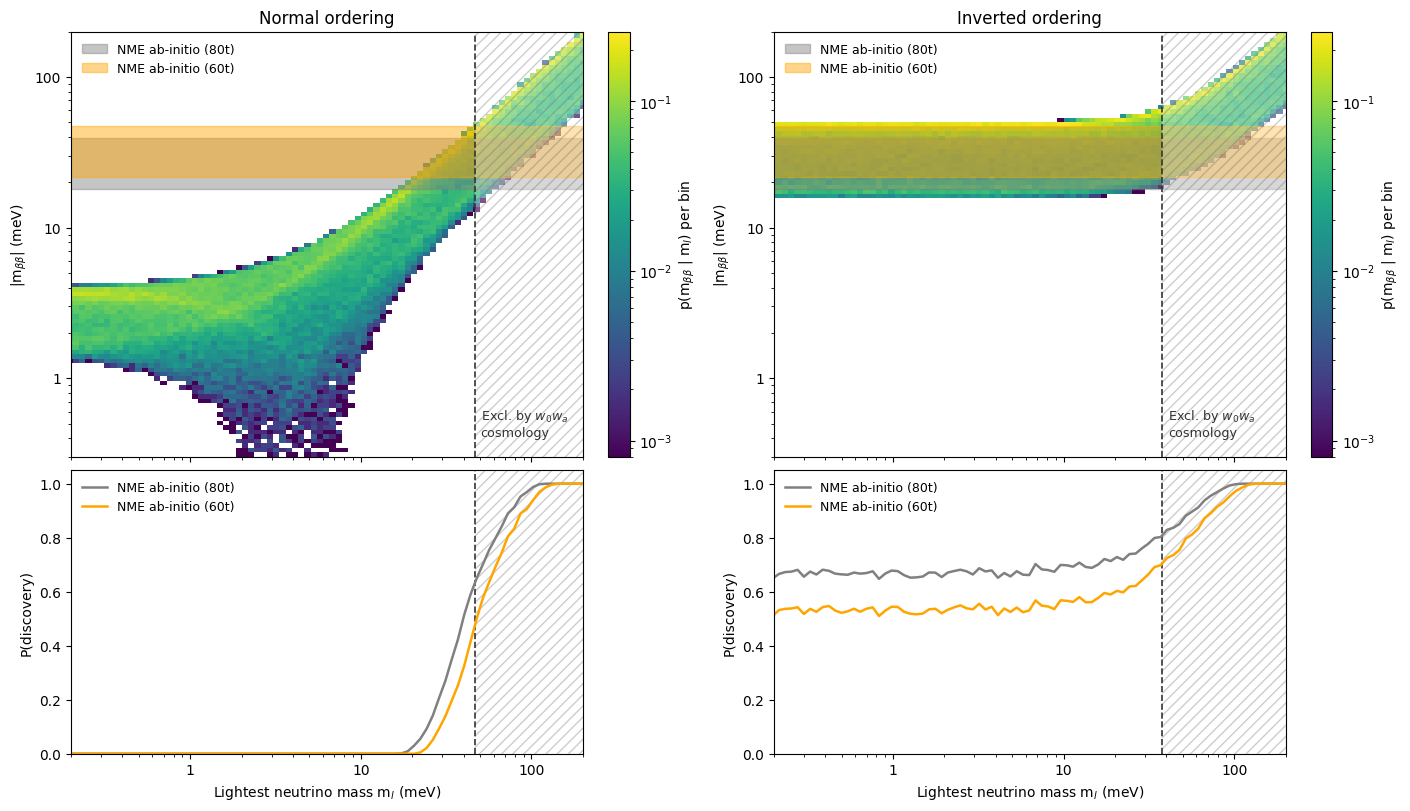

In [36]:

# 4-panel plot: density histograms (top) + discovery probability curves (bottom)
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter

_fmt = FuncFormatter(lambda x, _: f'{x:g}')

# ── Sensitivity weight per y-bin ──────────────────────────────────────────────
# band['upper'] is numerically smaller (best-case sensitivity threshold)
# band['lower'] is numerically larger (worst-case sensitivity threshold)
# w(mbb) = 0 for mbb < band['upper'], ramps to 1 at mbb = band['lower']
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])   # eV

def sensitivity_weights(y_centers, band):
    """Return per-bin weights in [0,1]: 0 below band, 1 above band, linear in between."""
    return np.clip(
        (y_centers - band['upper']) / (band['lower'] - band['upper']),
        0.0, 1.0
    )

w_80t = sensitivity_weights(y_centers, mbb_ab_initio_80t)
w_60t = sensitivity_weights(y_centers, mbb_ab_initio_60t)

# ── Discovery probability: P(disc | m_l) = Σ_i p(mbb_i | m_l) · w(mbb_i) ────
x_centers_meV = 0.5 * (x_edges_meV[:-1] + x_edges_meV[1:])

p_disc_no_80t = H_no_pdf @ w_80t   # shape (n_ml,)
p_disc_no_60t = H_no_pdf @ w_60t
p_disc_io_80t = H_io_pdf @ w_80t
p_disc_io_60t = H_io_pdf @ w_60t

# ── Build 4-panel figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 2, figsize=(14, 8),
    sharex='col',
    gridspec_kw={'height_ratios': [1.5, 1]},
    constrained_layout=True,
)

uniform_cmap = plt.get_cmap('viridis').copy()
uniform_cmap.set_bad(alpha=0.0)
norm_col = LogNorm(vmin=vmin, vmax=vmax)

# Convert NME bands to meV for horizontal reference lines
mbb_ab_initio_80t_meV = {k: v * 1e3 for k, v in mbb_ab_initio_80t.items()}
mbb_ab_initio_60t_meV = {k: v * 1e3 for k, v in mbb_ab_initio_60t.items()}

def add_cosmology_exclusion(ax, x_lim_right, cutoff_meV):
    ax.axvspan(cutoff_meV, x_lim_right, facecolor='white', alpha=0.32,
               hatch='///', edgecolor='0.4', linewidth=0.0)
    ax.axvline(cutoff_meV, color='0.2', linestyle='--', linewidth=1.2)

# ── Top-left: NO density ──────────────────────────────────────────────────────
ax = axes[0, 0]
pcm = ax.pcolormesh(x_edges_meV, y_edges_meV, H_no_pdf_masked.T,
                    shading='auto', cmap=uniform_cmap, norm=norm_col)
ax.set_title('Normal ordering')
ax.set_yscale('log')
ax.set_ylabel('|m$_{\\beta\\beta}$| (meV)')
ax.set_xlim(2e-1, 2e2)
ax.set_ylim(3e-1, 2e2)
ax.fill_between(x_edges_meV, mbb_ab_initio_80t_meV['upper'], mbb_ab_initio_80t_meV['lower'],
                color='gray', alpha=0.45, label='NME ab-initio (80t)')
ax.fill_between(x_edges_meV, mbb_ab_initio_60t_meV['upper'], mbb_ab_initio_60t_meV['lower'],
                color='orange', alpha=0.45, label='NME ab-initio (60t)')
add_cosmology_exclusion(ax, x_edges_meV[-1], m_l_NO_max_meV)
ax.text(1.08 * m_l_NO_max_meV, 3.9e-1,
        'Excl. by $w_0 w_a$\ncosmology', fontsize=9.2, color='0.2', rotation=0, va='bottom')
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.yaxis.set_major_formatter(_fmt)
cb = fig.colorbar(pcm, ax=ax)
cb.set_label('p(m$_{\\beta\\beta}$ | m$_l$) per bin')

# ── Top-right: IO density ─────────────────────────────────────────────────────
ax = axes[0, 1]
pcm = ax.pcolormesh(x_edges_meV, y_edges_meV, H_io_pdf_masked.T,
                    shading='auto', cmap=uniform_cmap, norm=norm_col)
ax.set_title('Inverted ordering')
ax.set_yscale('log')
ax.set_ylabel('|m$_{\\beta\\beta}$| (meV)')
ax.set_xlim(2e-1, 2e2)
ax.set_ylim(3e-1, 2e2)
ax.fill_between(x_edges_meV, mbb_ab_initio_80t_meV['upper'], mbb_ab_initio_80t_meV['lower'],
                color='gray', alpha=0.45, label='NME ab-initio (80t)')
ax.fill_between(x_edges_meV, mbb_ab_initio_60t_meV['upper'], mbb_ab_initio_60t_meV['lower'],
                color='orange', alpha=0.45, label='NME ab-initio (60t)')
add_cosmology_exclusion(ax, x_edges_meV[-1], m_l_IO_max_meV)
ax.text(1.08 * m_l_IO_max_meV, 3.9e-1,
        'Excl. by $w_0 w_a$\ncosmology', fontsize=9.2, color='0.2', rotation=0, va='bottom')
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.yaxis.set_major_formatter(_fmt)
cb = fig.colorbar(pcm, ax=ax)
cb.set_label('p(m$_{\\beta\\beta}$ | m$_l$) per bin')

# ── Bottom-left: NO discovery probability ─────────────────────────────────────
ax = axes[1, 0]
add_cosmology_exclusion(ax, x_edges_meV[-1], m_l_NO_max_meV)
ax.plot(x_centers_meV, p_disc_no_80t, color='gray',   lw=1.8, label='NME ab-initio (80t)')
ax.plot(x_centers_meV, p_disc_no_60t, color='orange', lw=1.8, label='NME ab-initio (60t)')
ax.set_xscale('log')
ax.set_xlabel('Lightest neutrino mass m$_l$ (meV)')
ax.set_ylabel('P(discovery)')
ax.set_xlim(2e-1, 2e2)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.xaxis.set_major_formatter(_fmt)

# ── Bottom-right: IO discovery probability ────────────────────────────────────
ax = axes[1, 1]
add_cosmology_exclusion(ax, x_edges_meV[-1], m_l_IO_max_meV)
ax.plot(x_centers_meV, p_disc_io_80t, color='gray',   lw=1.8, label='NME ab-initio (80t)')
ax.plot(x_centers_meV, p_disc_io_60t, color='orange', lw=1.8, label='NME ab-initio (60t)')
ax.set_xscale('log')
ax.set_xlabel('Lightest neutrino mass m$_l$ (meV)')
ax.set_ylabel('P(discovery)')
ax.set_xlim(2e-1, 2e2)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.xaxis.set_major_formatter(_fmt)

plt.show()


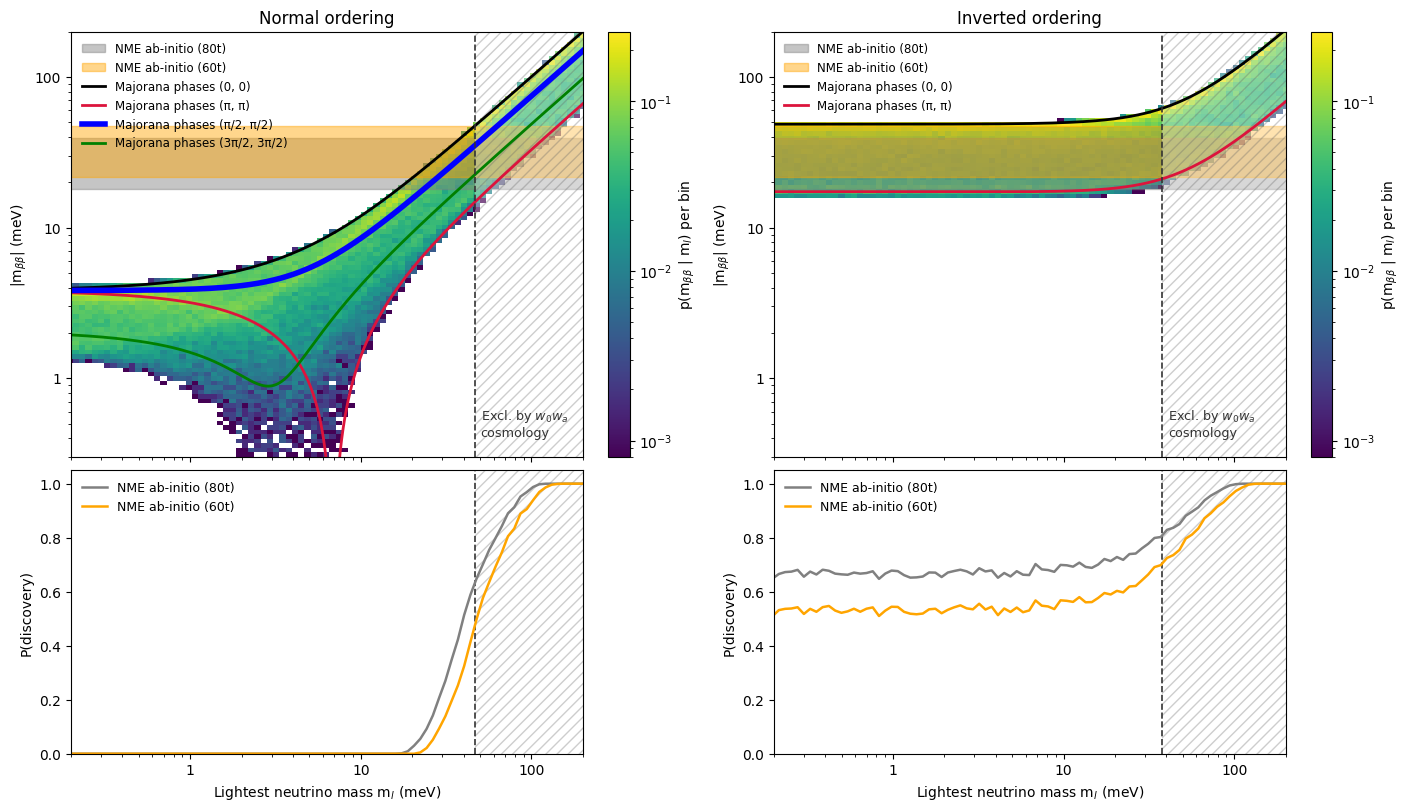

In [47]:
# 4-panel plot with phase-extreme solid lines on the density panels
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter

_fmt = FuncFormatter(lambda x, _: f'{x:g}')

# ── Sensitivity weight per y-bin ──────────────────────────────────────────────
# band['upper'] is numerically smaller (best-case sensitivity threshold)
# band['lower'] is numerically larger (worst-case sensitivity threshold)
# w(mbb) = 0 for mbb < band['upper'], ramps to 1 at mbb = band['lower']
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])   # eV

def sensitivity_weights(y_centers, band):
    """Return per-bin weights in [0,1]: 0 below band, 1 above band, linear in between."""
    return np.clip(
        (y_centers - band['upper']) / (band['lower'] - band['upper']),
        0.0, 1.0
    )

w_80t = sensitivity_weights(y_centers, mbb_ab_initio_80t)
w_60t = sensitivity_weights(y_centers, mbb_ab_initio_60t)

# ── Discovery probability: P(disc | m_l) = Σ_i p(mbb_i | m_l) · w(mbb_i) ────
x_centers_meV = 0.5 * (x_edges_meV[:-1] + x_edges_meV[1:])

p_disc_no_80t = H_no_pdf @ w_80t   # shape (n_ml,)
p_disc_no_60t = H_no_pdf @ w_60t
p_disc_io_80t = H_io_pdf @ w_80t
p_disc_io_60t = H_io_pdf @ w_60t

# Phase-extreme curves for the top panels
m_l_phase_meV = np.logspace(np.log10(2e-1), np.log10(2e2), 400)
m_l_phase_eV = m_l_phase_meV * 1e-3

def phase_curve(params_dict, ordering, delta_a1, delta_a2):
    return 1e3 * majorana_mass(
        params_dict,
        ordering=ordering,
        delta_a1=delta_a1,
        delta_a2=delta_a2,
        m_l=m_l_phase_eV,
    )

mbb_no_00 = phase_curve(params_dict_NO, 'NO', 0.0, 0.0)
mbb_no_pp = phase_curve(params_dict_NO, 'NO', np.pi, np.pi)
mbb_no_p2p2 = phase_curve(params_dict_NO, 'NO', np.pi/2., np.pi/2.)
mbb_no_3p23p2 = phase_curve(params_dict_NO, 'NO', 3*np.pi/4., 3*np.pi/2.)
mbb_io_00 = phase_curve(params_dict_IO, 'IO', 0.0, 0.0)
mbb_io_pp = phase_curve(params_dict_IO, 'IO', np.pi, np.pi)

# ── Build 4-panel figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 2, figsize=(14, 8),
    sharex='col',
    gridspec_kw={'height_ratios': [1.5, 1]},
    constrained_layout=True,
)

uniform_cmap = plt.get_cmap('viridis').copy()
uniform_cmap.set_bad(alpha=0.0)
norm_col = LogNorm(vmin=vmin, vmax=vmax)

# Convert NME bands to meV for horizontal reference lines
mbb_ab_initio_80t_meV = {k: v * 1e3 for k, v in mbb_ab_initio_80t.items()}
mbb_ab_initio_60t_meV = {k: v * 1e3 for k, v in mbb_ab_initio_60t.items()}

def add_cosmology_exclusion(ax, x_lim_right, cutoff_meV):
    ax.axvspan(cutoff_meV, x_lim_right, facecolor='white', alpha=0.32,
               hatch='///', edgecolor='0.4', linewidth=0.0)
    ax.axvline(cutoff_meV, color='0.2', linestyle='--', linewidth=1.2)

# ── Top-left: NO density ──────────────────────────────────────────────────────
ax = axes[0, 0]
pcm = ax.pcolormesh(x_edges_meV, y_edges_meV, H_no_pdf.T,
                    shading='auto', cmap=uniform_cmap, norm=norm_col)
ax.set_title('Normal ordering')
ax.set_yscale('log')
ax.set_ylabel('|m$_{\\beta\\beta}$| (meV)')
ax.set_xlim(2e-1, 2e2)
ax.set_ylim(3e-1, 2e2)
ax.fill_between(x_edges_meV, mbb_ab_initio_80t_meV['upper'], mbb_ab_initio_80t_meV['lower'],
                color='gray', alpha=0.45, label='NME ab-initio (80t)')
ax.fill_between(x_edges_meV, mbb_ab_initio_60t_meV['upper'], mbb_ab_initio_60t_meV['lower'],
                color='orange', alpha=0.45, label='NME ab-initio (60t)')
ax.plot(m_l_phase_meV, mbb_no_00, color='black', lw=2.0, label='Majorana phases (0, 0)')
ax.plot(m_l_phase_meV, mbb_no_pp, color='crimson', lw=2.0, label='Majorana phases (π, π)')
ax.plot(m_l_phase_meV, mbb_no_p2p2, color='blue', lw=4.0, label='Majorana phases (π/2, π/2)')
ax.plot(m_l_phase_meV, mbb_no_3p23p2, color='green', lw=2.0, label='Majorana phases (3π/2, 3π/2)')
add_cosmology_exclusion(ax, x_edges_meV[-1], m_l_NO_max_meV)
ax.text(1.08 * m_l_NO_max_meV, 3.9e-1,
        'Excl. by $w_0 w_a$\ncosmology', fontsize=9.2, color='0.2', rotation=0, va='bottom')
ax.legend(loc='upper left', fontsize=8.5, frameon=False)
ax.yaxis.set_major_formatter(_fmt)
cb = fig.colorbar(pcm, ax=ax)
cb.set_label('p(m$_{\\beta\\beta}$ | m$_l$) per bin')

# ── Top-right: IO density ─────────────────────────────────────────────────────
ax = axes[0, 1]
pcm = ax.pcolormesh(x_edges_meV, y_edges_meV, H_io_pdf.T,
                    shading='auto', cmap=uniform_cmap, norm=norm_col)
ax.set_title('Inverted ordering')
ax.set_yscale('log')
ax.set_ylabel('|m$_{\\beta\\beta}$| (meV)')
ax.set_xlim(2e-1, 2e2)
ax.set_ylim(3e-1, 2e2)
ax.fill_between(x_edges_meV, mbb_ab_initio_80t_meV['upper'], mbb_ab_initio_80t_meV['lower'],
                color='gray', alpha=0.45, label='NME ab-initio (80t)')
ax.fill_between(x_edges_meV, mbb_ab_initio_60t_meV['upper'], mbb_ab_initio_60t_meV['lower'],
                color='orange', alpha=0.45, label='NME ab-initio (60t)')
ax.plot(m_l_phase_meV, mbb_io_00, color='black', lw=2.0, label='Majorana phases (0, 0)')
ax.plot(m_l_phase_meV, mbb_io_pp, color='crimson', lw=2.0, label='Majorana phases (π, π)')
add_cosmology_exclusion(ax, x_edges_meV[-1], m_l_IO_max_meV)
ax.text(1.08 * m_l_IO_max_meV, 3.9e-1,
        'Excl. by $w_0 w_a$\ncosmology', fontsize=9.2, color='0.2', rotation=0, va='bottom')
ax.legend(loc='upper left', fontsize=8.5, frameon=False)
ax.yaxis.set_major_formatter(_fmt)
cb = fig.colorbar(pcm, ax=ax)
cb.set_label('p(m$_{\\beta\\beta}$ | m$_l$) per bin')

# ── Bottom-left: NO discovery probability ─────────────────────────────────────
ax = axes[1, 0]
add_cosmology_exclusion(ax, x_edges_meV[-1], m_l_NO_max_meV)
ax.plot(x_centers_meV, p_disc_no_80t, color='gray',   lw=1.8, label='NME ab-initio (80t)')
ax.plot(x_centers_meV, p_disc_no_60t, color='orange', lw=1.8, label='NME ab-initio (60t)')
ax.set_xscale('log')
ax.set_xlabel('Lightest neutrino mass m$_l$ (meV)')
ax.set_ylabel('P(discovery)')
ax.set_xlim(2e-1, 2e2)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.xaxis.set_major_formatter(_fmt)

# ── Bottom-right: IO discovery probability ────────────────────────────────────
ax = axes[1, 1]
add_cosmology_exclusion(ax, x_edges_meV[-1], m_l_IO_max_meV)
ax.plot(x_centers_meV, p_disc_io_80t, color='gray',   lw=1.8, label='NME ab-initio (80t)')
ax.plot(x_centers_meV, p_disc_io_60t, color='orange', lw=1.8, label='NME ab-initio (60t)')
ax.set_xscale('log')
ax.set_xlabel('Lightest neutrino mass m$_l$ (meV)')
ax.set_ylabel('P(discovery)')
ax.set_xlim(2e-1, 2e2)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.xaxis.set_major_formatter(_fmt)

plt.show()


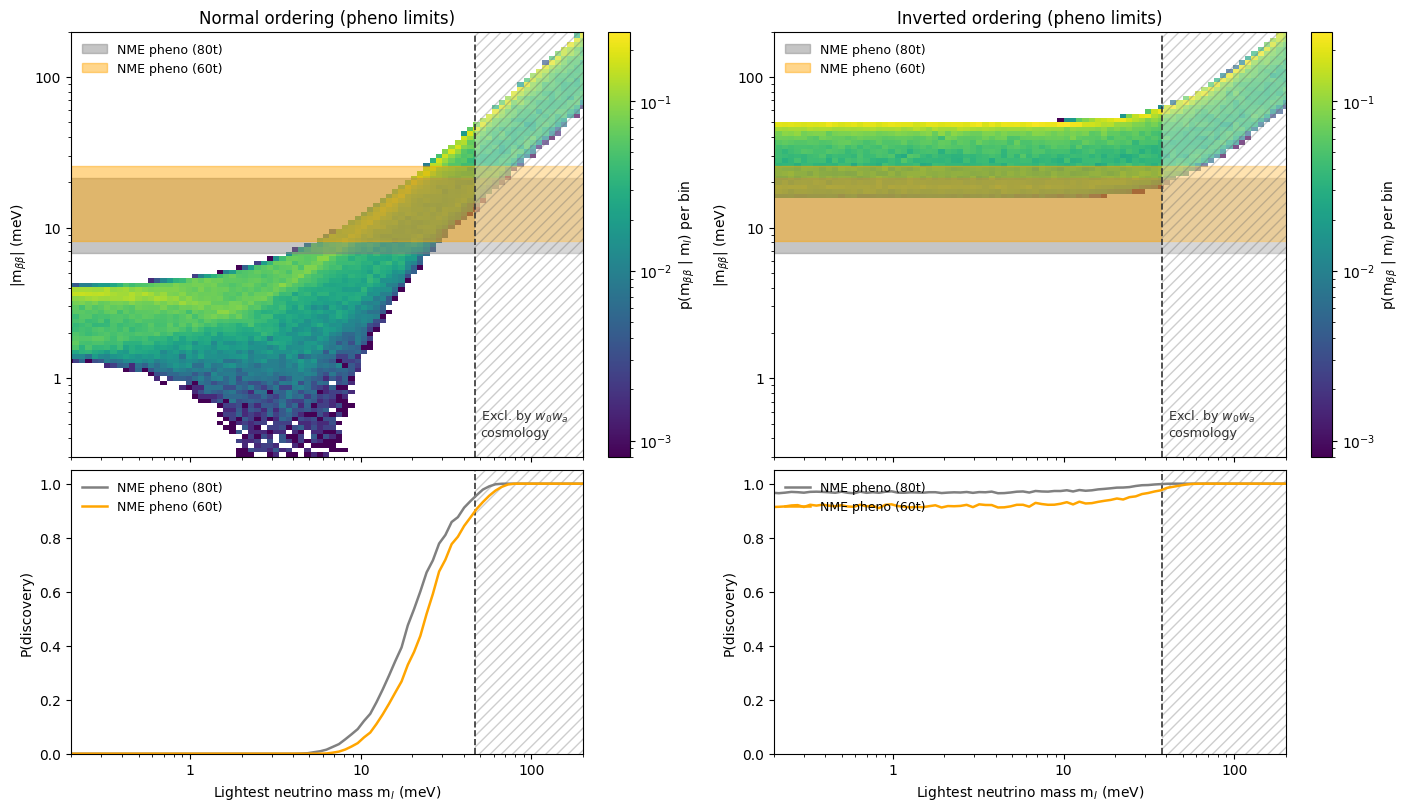

In [38]:

# 4-panel plot using pheno NME limits: density histograms (top) + discovery probability curves (bottom)
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter

_fmt = FuncFormatter(lambda x, _: f'{x:g}')

y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])   # eV

def sensitivity_weights(y_centers, band):
    """Return per-bin weights in [0,1]: 0 below band, 1 above band, linear in between."""
    return np.clip(
        (y_centers - band['upper']) / (band['lower'] - band['upper']),
        0.0, 1.0
    )

w_80t_pheno = sensitivity_weights(y_centers, mbb_pheno_80t)
w_60t_pheno = sensitivity_weights(y_centers, mbb_pheno_60t)

x_centers_meV = 0.5 * (x_edges_meV[:-1] + x_edges_meV[1:])

p_disc_no_80t_pheno = H_no_pdf @ w_80t_pheno
p_disc_no_60t_pheno = H_no_pdf @ w_60t_pheno
p_disc_io_80t_pheno = H_io_pdf @ w_80t_pheno
p_disc_io_60t_pheno = H_io_pdf @ w_60t_pheno

fig, axes = plt.subplots(
    2, 2, figsize=(14, 8),
    sharex='col',
    gridspec_kw={'height_ratios': [1.5, 1]},
    constrained_layout=True,
)

uniform_cmap = plt.get_cmap('viridis').copy()
uniform_cmap.set_bad(alpha=0.0)
norm_col = LogNorm(vmin=vmin, vmax=vmax)

mbb_pheno_80t_meV = {k: v * 1e3 for k, v in mbb_pheno_80t.items()}
mbb_pheno_60t_meV = {k: v * 1e3 for k, v in mbb_pheno_60t.items()}

def add_cosmology_exclusion(ax, x_lim_right, cutoff_meV):
    ax.axvspan(cutoff_meV, x_lim_right, facecolor='white', alpha=0.32,
               hatch='///', edgecolor='0.4', linewidth=0.0)
    ax.axvline(cutoff_meV, color='0.2', linestyle='--', linewidth=1.2)

# Top-left: NO density
ax = axes[0, 0]
pcm = ax.pcolormesh(x_edges_meV, y_edges_meV, H_no_pdf_masked.T,
                    shading='auto', cmap=uniform_cmap, norm=norm_col)
ax.set_title('Normal ordering (pheno limits)')
ax.set_yscale('log')
ax.set_ylabel('|m$_{\\beta\\beta}$| (meV)')
ax.set_xlim(2e-1, 2e2)
ax.set_ylim(3e-1, 2e2)
ax.fill_between(x_edges_meV, mbb_pheno_80t_meV['upper'], mbb_pheno_80t_meV['lower'],
                color='gray', alpha=0.45, label='NME pheno (80t)')
ax.fill_between(x_edges_meV, mbb_pheno_60t_meV['upper'], mbb_pheno_60t_meV['lower'],
                color='orange', alpha=0.45, label='NME pheno (60t)')
add_cosmology_exclusion(ax, x_edges_meV[-1], m_l_NO_max_meV)
ax.text(1.08 * m_l_NO_max_meV, 3.9e-1,
        'Excl. by $w_0 w_a$\ncosmology', fontsize=9.2, color='0.2', rotation=0, va='bottom')
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.yaxis.set_major_formatter(_fmt)
cb = fig.colorbar(pcm, ax=ax)
cb.set_label('p(m$_{\\beta\\beta}$ | m$_l$) per bin')

# Top-right: IO density
ax = axes[0, 1]
pcm = ax.pcolormesh(x_edges_meV, y_edges_meV, H_io_pdf_masked.T,
                    shading='auto', cmap=uniform_cmap, norm=norm_col)
ax.set_title('Inverted ordering (pheno limits)')
ax.set_yscale('log')
ax.set_ylabel('|m$_{\\beta\\beta}$| (meV)')
ax.set_xlim(2e-1, 2e2)
ax.set_ylim(3e-1, 2e2)
ax.fill_between(x_edges_meV, mbb_pheno_80t_meV['upper'], mbb_pheno_80t_meV['lower'],
                color='gray', alpha=0.45, label='NME pheno (80t)')
ax.fill_between(x_edges_meV, mbb_pheno_60t_meV['upper'], mbb_pheno_60t_meV['lower'],
                color='orange', alpha=0.45, label='NME pheno (60t)')
add_cosmology_exclusion(ax, x_edges_meV[-1], m_l_IO_max_meV)
ax.text(1.08 * m_l_IO_max_meV, 3.9e-1,
        'Excl. by $w_0 w_a$\ncosmology', fontsize=9.2, color='0.2', rotation=0, va='bottom')
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.yaxis.set_major_formatter(_fmt)
cb = fig.colorbar(pcm, ax=ax)
cb.set_label('p(m$_{\\beta\\beta}$ | m$_l$) per bin')

# Bottom-left: NO discovery probability
ax = axes[1, 0]
add_cosmology_exclusion(ax, x_edges_meV[-1], m_l_NO_max_meV)
ax.plot(x_centers_meV, p_disc_no_80t_pheno, color='gray',   lw=1.8, label='NME pheno (80t)')
ax.plot(x_centers_meV, p_disc_no_60t_pheno, color='orange', lw=1.8, label='NME pheno (60t)')
ax.set_xscale('log')
ax.set_xlabel('Lightest neutrino mass m$_l$ (meV)')
ax.set_ylabel('P(discovery)')
ax.set_xlim(2e-1, 2e2)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.xaxis.set_major_formatter(_fmt)

# Bottom-right: IO discovery probability
ax = axes[1, 1]
add_cosmology_exclusion(ax, x_edges_meV[-1], m_l_IO_max_meV)
ax.plot(x_centers_meV, p_disc_io_80t_pheno, color='gray',   lw=1.8, label='NME pheno (80t)')
ax.plot(x_centers_meV, p_disc_io_60t_pheno, color='orange', lw=1.8, label='NME pheno (60t)')
ax.set_xscale('log')
ax.set_xlabel('Lightest neutrino mass m$_l$ (meV)')
ax.set_ylabel('P(discovery)')
ax.set_xlim(2e-1, 2e2)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.xaxis.set_major_formatter(_fmt)

plt.show()


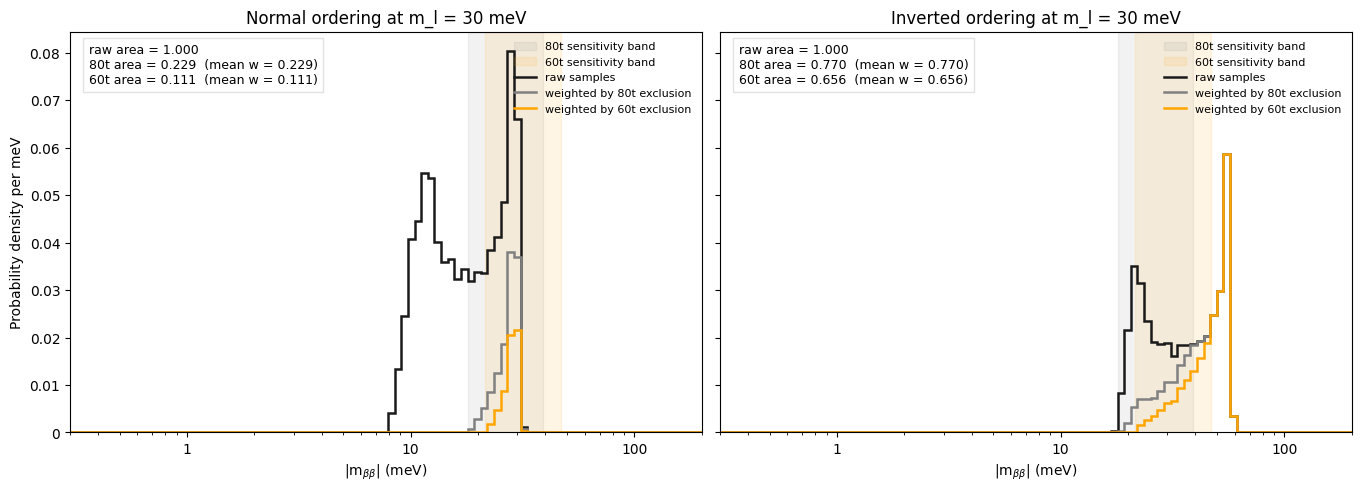

In [39]:

# 1D cross-check at fixed m_l = 30 meV: raw m_bb samples vs weighted distributions
from matplotlib.ticker import FuncFormatter

_fmt = FuncFormatter(lambda x, _: f'{x:g}')
m_l_slice = 30e-3  # eV
n_slice_samples = 12000
slice_rng = np.random.default_rng(11)

# Reuse the same y-bin edges as the 2D density plots, but work in meV for readability.
slice_bins_meV = y_edges_meV
slice_bin_widths_meV = np.diff(slice_bins_meV)

def exclusion_weights(samples_eV, band):
    return np.clip((samples_eV - band['upper']) / (band['lower'] - band['upper']), 0.0, 1.0)


def histogram_density(samples_meV, bins_meV, weights=None):
    counts, edges = np.histogram(samples_meV, bins=bins_meV, weights=weights)
    density = counts / (samples_meV.size * np.diff(edges))
    area = np.sum(density * np.diff(edges))
    return density, edges, area


def slice_distributions(params_dict, ordering, band_80t, band_60t):
    samples_eV = sample_mbb_at_mlightest(
        m_l_slice,
        params_dict,
        ordering=ordering,
        n_samples=n_slice_samples,
        rng=slice_rng,
    )
    samples_meV = samples_eV * 1e3

    raw_density, edges, raw_area = histogram_density(samples_meV, slice_bins_meV)
    weights_80t = exclusion_weights(samples_eV, band_80t)
    weights_60t = exclusion_weights(samples_eV, band_60t)
    weighted_80t, _, area_80t = histogram_density(samples_meV, slice_bins_meV, weights=weights_80t)
    weighted_60t, _, area_60t = histogram_density(samples_meV, slice_bins_meV, weights=weights_60t)

    return {
        'samples_meV': samples_meV,
        'raw_density': raw_density,
        'weighted_80t': weighted_80t,
        'weighted_60t': weighted_60t,
        'edges': edges,
        'raw_area': raw_area,
        'area_80t': area_80t,
        'area_60t': area_60t,
        'mean_80t': weights_80t.mean(),
        'mean_60t': weights_60t.mean(),
    }

no_slice = slice_distributions(params_dict_NO, 'NO', mbb_ab_initio_80t, mbb_ab_initio_60t)
io_slice = slice_distributions(params_dict_IO, 'IO', mbb_ab_initio_80t, mbb_ab_initio_60t)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=True, constrained_layout=True)

panels = [
    (axes[0], 'Normal ordering', no_slice),
    (axes[1], 'Inverted ordering', io_slice),
]

for ax, title, data in panels:
    ax.set_title(f'{title} at m_l = {m_l_slice * 1e3:.0f} meV')
    ax.axvspan(mbb_ab_initio_80t['upper'] * 1e3, mbb_ab_initio_80t['lower'] * 1e3,
               color='gray', alpha=0.10, label='80t sensitivity band')
    ax.axvspan(mbb_ab_initio_60t['upper'] * 1e3, mbb_ab_initio_60t['lower'] * 1e3,
               color='orange', alpha=0.10, label='60t sensitivity band')
    ax.stairs(data['raw_density'], data['edges'], color='0.1', linewidth=1.8, label='raw samples')
    ax.stairs(data['weighted_80t'], data['edges'], color='gray', linewidth=1.8, label='weighted by 80t exclusion')
    ax.stairs(data['weighted_60t'], data['edges'], color='orange', linewidth=1.8, label='weighted by 60t exclusion')
    ax.set_xscale('log')
    ax.set_xlabel('|m$_{\\beta\\beta}$| (meV)')
    ax.set_xlim(3e-1, 2e2)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_formatter(_fmt)
    ax.yaxis.set_major_formatter(_fmt)
    ax.text(
        0.03, 0.97,
        f"raw area = {data['raw_area']:.3f}\n"
        f"80t area = {data['area_80t']:.3f}  (mean w = {data['mean_80t']:.3f})\n"
        f"60t area = {data['area_60t']:.3f}  (mean w = {data['mean_60t']:.3f})",
        transform=ax.transAxes,
        ha='left', va='top', fontsize=9,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='0.85'),
    )

axes[0].set_ylabel('Probability density per meV')
axes[0].legend(loc='upper right', fontsize=8, frameon=False)
axes[1].legend(loc='upper right', fontsize=8, frameon=False)

plt.show()
